###Step 1: Importing Libraries

This section imports the required libraries for:

- data manipulation
- visualization
- feature engineering
- machine learning
- model evaluation
- model storage

In [48]:
import pandas as pd              
import numpy as np     
import matplotlib.pyplot as plt   
import seaborn as sns             

In [49]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             average_precision_score, f1_score)




In [50]:
import warnings
import os
warnings.filterwarnings('ignore')


In [51]:
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(" All libraries imported successfully!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")


 All libraries imported successfully!
   pandas  : 2.3.3
   numpy   : 2.3.5


In [52]:
import sys
import os



NOTEBOOK_DIR = os.getcwd()          
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)  

sys.path.append(os.path.join(PROJECT_ROOT, 'src'))

DATA_PATH  = os.path.join(PROJECT_ROOT, 'data',    'Smart_Parking_Management.csv')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs') + os.sep
MODEL_DIR  = os.path.join(PROJECT_ROOT, 'models')  + os.sep

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_PATH    : {DATA_PATH}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"MODEL_DIR    : {MODEL_DIR}")

PROJECT_ROOT : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction
DATA_PATH    : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\data\Smart_Parking_Management.csv
OUTPUT_DIR   : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\outputs\
MODEL_DIR    : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\


In [53]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

print(" Paths configured!")
print(f"   Data    : {DATA_PATH}")
print(f"   Outputs : {OUTPUT_DIR}")
print(f"   Models  : {MODEL_DIR}")

 Paths configured!
   Data    : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\data\Smart_Parking_Management.csv
   Outputs : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\outputs\
   Models  : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\


## Step 2 — Load & Inspect Data

The dataset is loaded and inspected to understand:

- dataset dimensions
- feature types
- missing values
- target distribution
- categorical and numerical columns

Initial inspection helps identify data quality issues before modelling.

In [54]:
df = pd.read_csv(DATA_PATH)

print(f" Dataset loaded!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")

 Dataset loaded!
   Rows    : 1000
   Columns : 28


In [55]:

df.head()

,Timestamp,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,User_Type,Weather_Temperature,Weather_Precipitation,Nearby_Traffic_Level,...,Occupancy_Status,Vehicle_Type,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Spot_Size,Proximity_To_Exit,User_Parking_History
0,2021-01-01 00:00:00.000000000,20,1.023651,1.541461,1831.770127,4.392528,Visitor,18.092553,1,Low,...,Occupied,Car,0,102.951052,4,55.620740,0.8,Standard,6.610474,6.660310
1,2021-01-02 06:39:16.756756756,49,3.903349,1.621719,1330.815754,4.595638,Registered,13.397533,0,Low,...,Occupied,Car,0,87.559131,3,56.682386,1.2,Compact,8.678719,6.766187
2,2021-01-03 13:18:33.513513513,38,10.315709,6.292374,1255.134827,4.313721,Registered,21.687410,0,High,...,Vacant,Car,1,100.061854,5,59.239322,0.8,Standard,13.795262,-0.910052
3,2021-01-04 19:57:50.270270270,31,6.588039,1.659870,1523.442919,3.567329,Visitor,18.683461,0,Medium,...,Vacant,Motorcycle,1,110.594598,2,44.545155,0.8,Standard,1.678721,10.415888
4,2021-01-06 02:37:07.027027027,8,8.213969,3.278467,1758.490837,5.145836,Visitor,19.214876,0,High,...,Occupied,Car,0,84.786963,2,48.012604,0.8,Standard,20.012252,4.355544


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  1000 non-null   object 
 1   Parking_Spot_ID            1000 non-null   int64  
 2   Sensor_Reading_Proximity   1000 non-null   float64
 3   Sensor_Reading_Pressure    1000 non-null   float64
 4   Vehicle_Type_Weight        1000 non-null   float64
 5   Vehicle_Type_Height        1000 non-null   float64
 6   User_Type                  1000 non-null   object 
 7   Weather_Temperature        1000 non-null   float64
 8   Weather_Precipitation      1000 non-null   int64  
 9   Nearby_Traffic_Level       1000 non-null   object 
 10  Entry_Time                 1000 non-null   int64  
 11  Exit_Time                  1000 non-null   int64  
 12  Electric_Vehicle           1000 non-null   int64  
 13  Reserved_Status            1000 non-null   int64 

In [57]:
# Check for missing values in every column
null_counts = df.isnull().sum()

print("Missing values per column:")
print(null_counts)
print(f"\nTotal missing values: {null_counts.sum()}")

Missing values per column:
Timestamp                    0
Parking_Spot_ID              0
Sensor_Reading_Proximity     0
Sensor_Reading_Pressure      0
Vehicle_Type_Weight          0
Vehicle_Type_Height          0
User_Type                    0
Weather_Temperature          0
Weather_Precipitation        0
Nearby_Traffic_Level         0
Entry_Time                   0
Exit_Time                    0
Electric_Vehicle             0
Reserved_Status              0
Occupancy_Rate               0
Payment_Amount               0
Parking_Lot_Section          0
Payment_Status               0
Occupancy_Status             0
Vehicle_Type                 0
Parking_Violation            0
Sensor_Reading_Ultrasonic    0
Parking_Duration             0
Environmental_Noise_Level    0
Dynamic_Pricing_Factor       0
Spot_Size                    0
Proximity_To_Exit            0
User_Parking_History         0
dtype: int64

Total missing values: 0


In [58]:
# Summary statistics for all numeric columns

df.describe().round(2)

,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,Weather_Temperature,Weather_Precipitation,Entry_Time,Exit_Time,Electric_Vehicle,Reserved_Status,Occupancy_Rate,Payment_Amount,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Proximity_To_Exit,User_Parking_History
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,25.50,5.18,4.04,1486.06,4.99,19.80,0.10,11.85,11.36,0.2,0.16,0.28,10.52,0.1,100.45,2.87,50.37,0.96,9.46,5.14
std,14.88,5.24,2.82,303.83,0.98,5.20,0.29,6.92,7.10,0.4,0.36,0.16,11.16,0.3,20.43,1.63,9.70,0.20,9.58,1.96
min,1.00,0.02,0.05,597.71,1.82,3.89,0.00,0.00,0.00,0.0,0.00,0.01,0.01,0.0,42.01,0.00,20.15,0.80,0.00,-1.81
25%,12.75,1.38,1.93,1284.74,4.33,16.26,0.00,6.00,5.00,0.0,0.00,0.16,3.02,0.0,86.56,2.00,43.42,0.80,2.81,3.79
50%,26.00,3.66,3.46,1486.16,4.99,19.71,0.00,12.00,11.00,0.0,0.00,0.26,7.01,0.0,99.96,3.00,50.33,0.80,6.69,5.09
75%,38.25,7.15,5.38,1675.79,5.66,23.48,0.00,18.00,18.00,0.0,0.00,0.39,13.84,0.0,114.31,4.00,56.90,1.00,12.99,6.43
max,50.00,37.21,27.22,2472.93,8.11,37.65,1.00,23.00,23.00,1.0,1.00,0.79,72.64,1.0,168.16,10.00,85.06,1.50,84.65,11.69


In [59]:



print("Target Column — Occupancy_Status")
print("="*35)
print(df['Occupancy_Status'].value_counts())
print()
print(f"Occupied % : {(df['Occupancy_Status']=='Occupied').mean()*100:.1f}%")
print(f"Vacant   % : {(df['Occupancy_Status']=='Vacant').mean()*100:.1f}%")

Target Column — Occupancy_Status
Occupancy_Status
Occupied    550
Vacant      450
Name: count, dtype: int64

Occupied % : 55.0%
Vacant   % : 45.0%


In [60]:


cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Timestamp')   # Timestamp is not a category

print("Categorical Columns & Their Unique Values")
print("="*45)
for col in cat_cols:
    print(f"\n  {col}:")
    print(f"    {df[col].unique()}")

Categorical Columns & Their Unique Values

  User_Type:
    ['Visitor' 'Registered' 'Staff']

  Nearby_Traffic_Level:
    ['Low' 'High' 'Medium']

  Parking_Lot_Section:
    ['Zone A' 'Zone B' 'Zone C' 'Zone D']

  Payment_Status:
    ['Paid' 'Unpaid' 'Overdue']

  Occupancy_Status:
    ['Occupied' 'Vacant']

  Vehicle_Type:
    ['Car' 'Motorcycle' 'Electric Vehicle']

  Spot_Size:
    ['Standard' 'Compact' 'Oversized']


## Step 3 — Data Cleaning

Data cleaning ensures consistency and reliability before model training.

The following operations are performed:

- timestamp conversion
- datatype correction
- duplicate checking
- sensor value validation
- target encoding

Clean data improves model performance and reduces noise.

In [61]:


df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(" Timestamp parsed successfully!")
print(f"   Earliest record : {df['Timestamp'].min()}")
print(f"   Latest record   : {df['Timestamp'].max()}")
print(f"   Date range      : {(df['Timestamp'].max() - df['Timestamp'].min()).days} days")
print(f"   Data type now   : {df['Timestamp'].dtype}")

 Timestamp parsed successfully!
   Earliest record : 2021-01-01 00:00:00
   Latest record   : 2024-06-30 00:00:00
   Date range      : 1276 days
   Data type now   : datetime64[ns]


In [62]:

# Some columns that look numeric might be stored as text
# We make sure everything is in the right format

# These should be integers (0 or 1 flags)
binary_cols = ['Electric_Vehicle', 'Reserved_Status', 'Parking_Violation']
for col in binary_cols:
    df[col] = df[col].astype(int)

# These should be floats (continuous measurements)
float_cols = ['Sensor_Reading_Proximity', 'Sensor_Reading_Pressure',
              'Sensor_Reading_Ultrasonic', 'Weather_Temperature',
              'Dynamic_Pricing_Factor', 'Environmental_Noise_Level',
              'Proximity_To_Exit', 'User_Parking_History',
              'Vehicle_Type_Weight', 'Vehicle_Type_Height']
for col in float_cols:
    df[col] = df[col].astype(float)

print("Data types fixed!")
print()
print(df[binary_cols + float_cols].dtypes)

Data types fixed!

Electric_Vehicle               int64
Reserved_Status                int64
Parking_Violation              int64
Sensor_Reading_Proximity     float64
Sensor_Reading_Pressure      float64
Sensor_Reading_Ultrasonic    float64
Weather_Temperature          float64
Dynamic_Pricing_Factor       float64
Environmental_Noise_Level    float64
Proximity_To_Exit            float64
User_Parking_History         float64
Vehicle_Type_Weight          float64
Vehicle_Type_Height          float64
dtype: object


In [63]:
# ── Duplicate Row Check ────────────────────────────────────
# Duplicate rows can silently inflate model accuracy


n_duplicates = df.duplicated().sum()

if n_duplicates > 0:
    print(f" Found {n_duplicates} duplicate rows — removing them")
    df = df.drop_duplicates().reset_index(drop=True)
else:
    print(f" No duplicate rows found!")

print(f"   Dataset shape after check: {df.shape}")

 No duplicate rows found!
   Dataset shape after check: (1000, 28)


In [64]:
# ── Sensor Range Validation ────────────────────────────────
# IIoT sensors can malfunction and report impossible values
# We check if readings are within physically valid ranges


sensor_checks = {
    'Sensor_Reading_Proximity'  : (0, 500),    # cm
    'Sensor_Reading_Pressure'   : (0, 10000),  # Pascals
    'Sensor_Reading_Ultrasonic' : (0, 500),    # cm
    'Weather_Temperature'       : (-20, 60),   # Celsius
    'Weather_Precipitation'     : (0, 500),    # mm
}

print("Sensor & Weather Range Validation")
print("="*50)
for col, (low, high) in sensor_checks.items():
    out_of_range = ((df[col] < low) | (df[col] > high)).sum()
    status = " OK" if out_of_range == 0 else f"  {out_of_range} outliers"
    print(f"  {col:<35} {status}")
    
    
    df[col] = df[col].clip(low, high)

print()
print(" All sensor values clipped to valid ranges")

Sensor & Weather Range Validation
  Sensor_Reading_Proximity             OK
  Sensor_Reading_Pressure              OK
  Sensor_Reading_Ultrasonic            OK
  Weather_Temperature                  OK
  Weather_Precipitation                OK

 All sensor values clipped to valid ranges


In [65]:
# ── Target Encoding ────────────────────────────────────────


df['occupied'] = (df['Occupancy_Status'] == 'Occupied').astype(int)

print("Target column encoded!")
print()
print("  Occupancy_Status → occupied")
print("  Occupied         → 1")
print("  Vacant           → 0")
print()
print(df['occupied'].value_counts())
print()
print(f"  Class balance: {df['occupied'].mean()*100:.1f}% occupied")

Target column encoded!

  Occupancy_Status → occupied
  Occupied         → 1
  Vacant           → 0

occupied
1    550
0    450
Name: count, dtype: int64

  Class balance: 55.0% occupied


In [66]:

# Save cleaned dataframe
df_clean = df.copy()
print("\n df_clean is ready for EDA!")


 df_clean is ready for EDA!


## Step 4 — Exploratory Data Analysis (EDA)

EDA is performed to identify:

- occupancy patterns
- temporal trends
- sensor behavior
- feature relationships
- important factors affecting parking occupancy

Visual analysis helps in understanding the dataset before feature engineering and model training.

### 4.1 — Occupancy Overview
This analysis examines:

- class distribution
- occupancy ratio
- parking spot utilization patterns

Understanding class balance is important before training classification models.

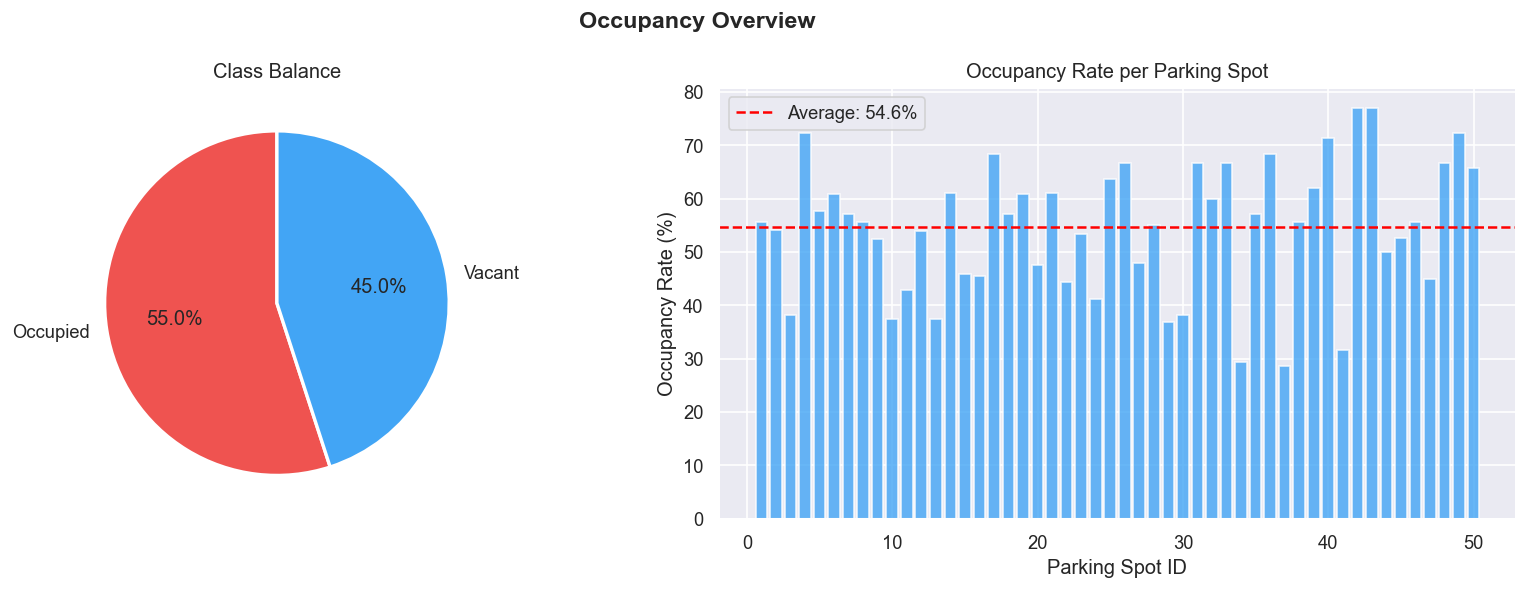

 Plot saved to outputs/


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Occupancy Overview", fontsize=14, fontweight='bold')

# ── Pie chart ──────────────────────────────────────────────
occ_counts = df_clean['Occupancy_Status'].value_counts()
colors = ['#EF5350', '#42A5F5']
axes[0].pie(occ_counts, labels=occ_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Class Balance")

# ── Bar chart per spot ─────────────────────────────────────
spot_occ = df_clean.groupby('Parking_Spot_ID')['occupied'].mean() * 100
axes[1].bar(spot_occ.index, spot_occ.values, color='#42A5F5', alpha=0.8)
axes[1].axhline(spot_occ.mean(), color='red', linestyle='--',
                label=f'Average: {spot_occ.mean():.1f}%')
axes[1].set_title("Occupancy Rate per Parking Spot")
axes[1].set_xlabel("Parking Spot ID")
axes[1].set_ylabel("Occupancy Rate (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}01_occupancy_overview.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to outputs/")

Observation:
The dataset shows a relatively balanced distribution between occupied and vacant parking states.

Insight:
Balanced classes reduce the risk of model bias and improve classification reliability.


### 4.2 — Temporal Patterns
This section analyzes occupancy trends across:

- hours of the day
- weekdays and weekends
- monthly variations

Parking demand is strongly influenced by time-based patterns.

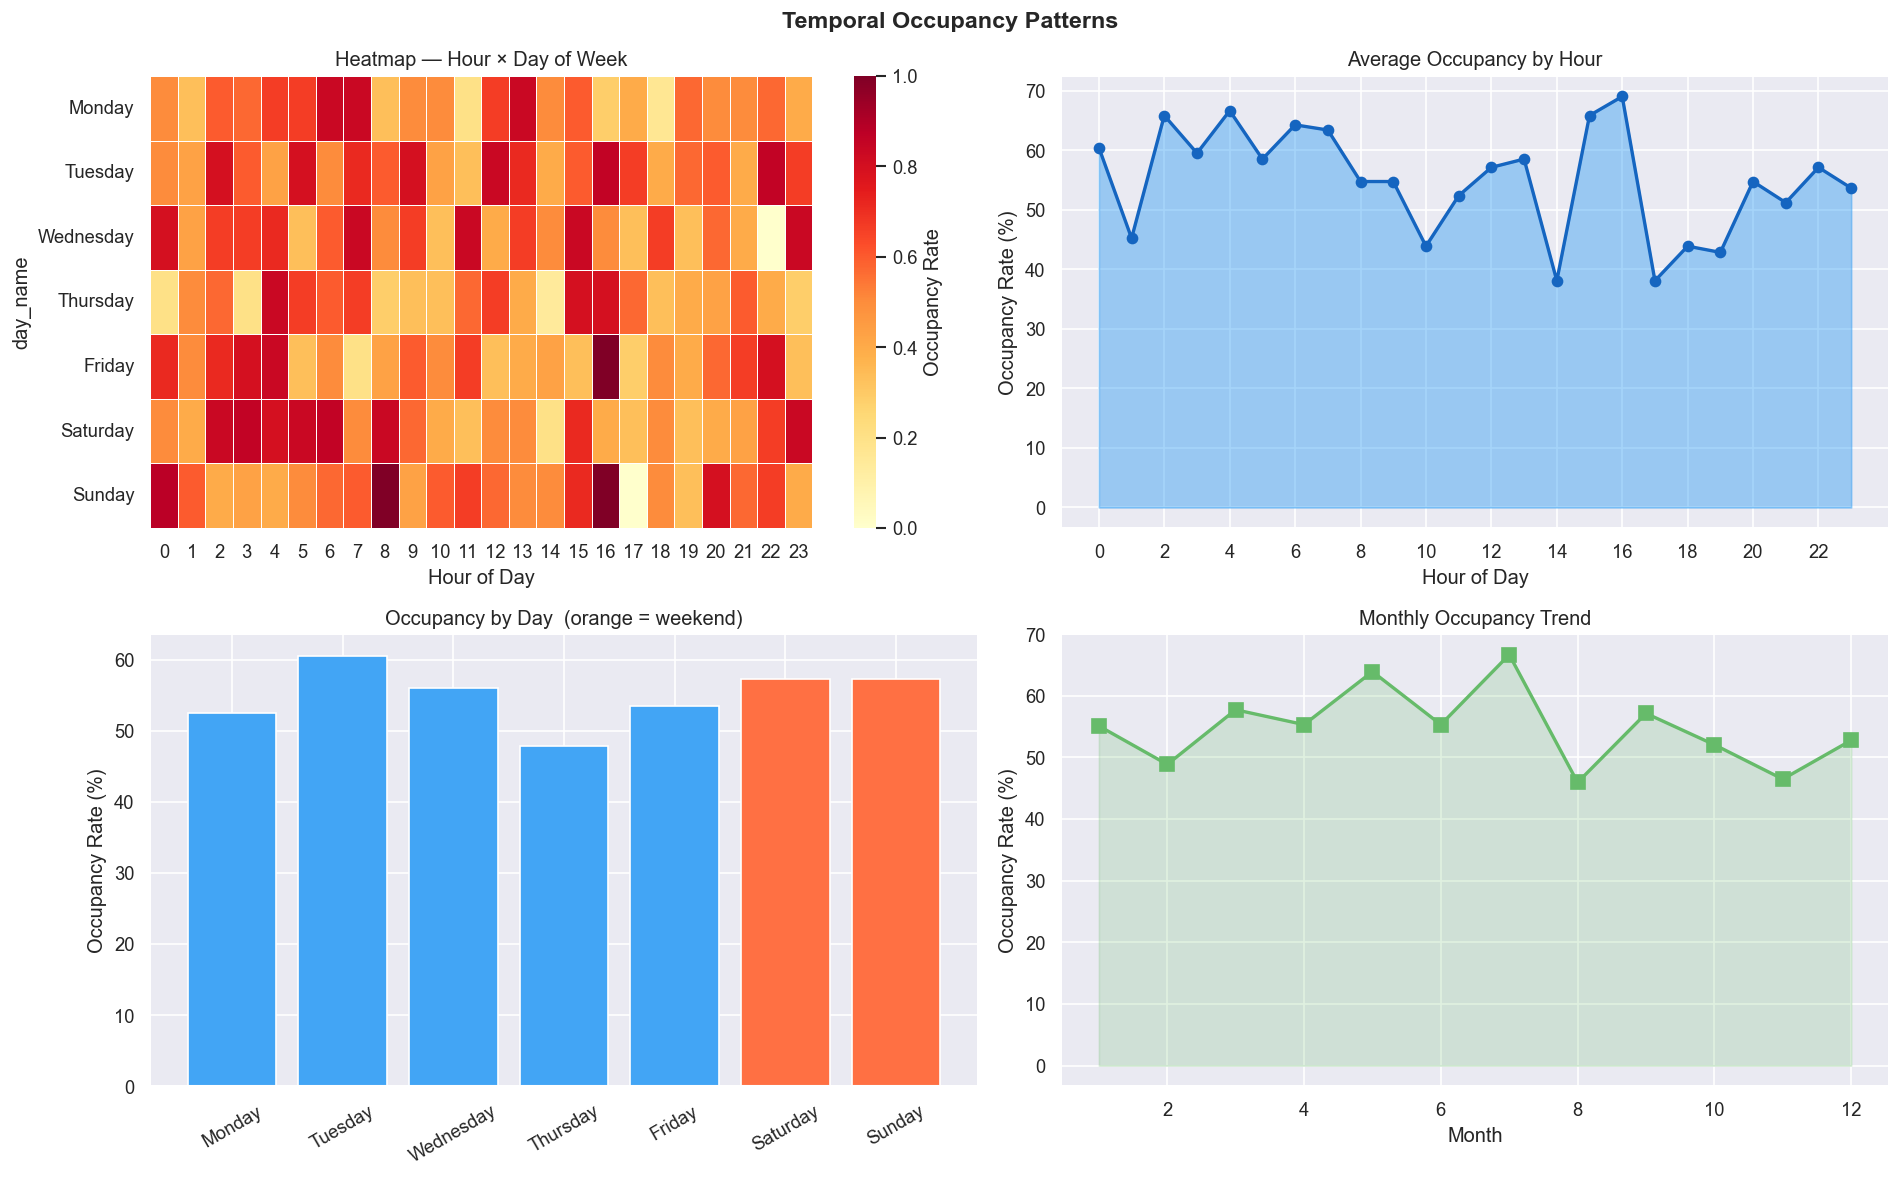

 Plot saved to outputs/


In [68]:

df_clean['hour']        = df_clean['Timestamp'].dt.hour
df_clean['day_of_week'] = df_clean['Timestamp'].dt.dayofweek
df_clean['day_name']    = df_clean['Timestamp'].dt.day_name()
df_clean['month']       = df_clean['Timestamp'].dt.month

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Temporal Occupancy Patterns", fontsize=14, fontweight='bold')

# ── Heatmap: hour × day ────────────────────────────────────
pivot = df_clean.groupby(['day_name','hour'])['occupied'].mean().unstack()
pivot = pivot.reindex(day_order)
sns.heatmap(pivot, ax=axes[0,0], cmap='YlOrRd',
            linewidths=0.3,
            cbar_kws={'label':'Occupancy Rate'})
axes[0,0].set_title("Heatmap — Hour × Day of Week")
axes[0,0].set_xlabel("Hour of Day")

# ── Hourly average ─────────────────────────────────────────
hourly = df_clean.groupby('hour')['occupied'].mean() * 100
axes[0,1].fill_between(hourly.index, hourly.values,
                        alpha=0.4, color='#2196F3')
axes[0,1].plot(hourly.index, hourly.values,
               'o-', color='#1565C0', linewidth=2)
axes[0,1].set_title("Average Occupancy by Hour")
axes[0,1].set_xlabel("Hour of Day")
axes[0,1].set_ylabel("Occupancy Rate (%)")
axes[0,1].set_xticks(range(0, 24, 2))

# ── Day of week ────────────────────────────────────────────
daily = df_clean.groupby('day_name')['occupied'].mean()
daily = daily.reindex(day_order) * 100
bar_colors = ['#FF7043' if d in ['Saturday','Sunday']
              else '#42A5F5' for d in day_order]
axes[1,0].bar(day_order, daily.values,
              color=bar_colors, edgecolor='white')
axes[1,0].set_title("Occupancy by Day  (orange = weekend)")
axes[1,0].set_ylabel("Occupancy Rate (%)")
axes[1,0].tick_params(axis='x', rotation=30)

# ── Monthly trend ──────────────────────────────────────────
monthly = df_clean.groupby('month')['occupied'].mean() * 100
axes[1,1].plot(monthly.index, monthly.values,
               's-', color='#66BB6A', linewidth=2, markersize=8)
axes[1,1].fill_between(monthly.index, monthly.values,
                        alpha=0.2, color='#66BB6A')
axes[1,1].set_title("Monthly Occupancy Trend")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Occupancy Rate (%)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}02_temporal_patterns.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to outputs/")

Observation:
- Occupancy levels are higher during daytime working hours and lower  during late-night periods.
- Weekday occupancy is generally higher than weekend occupancy.


Insight:
- Parking demand strongly depends on temporal patterns, making time-based features important for prediction.
- Commercial and office-area parking usage contributes to higher weekday demand.

### 4.3 — Sensor Analysis
Sensor readings are analyzed to determine whether occupied and vacant parking spots show distinct patterns.

The analysis helps evaluate the predictive strength of:

- proximity sensor
- pressure sensor
- ultrasonic sensor

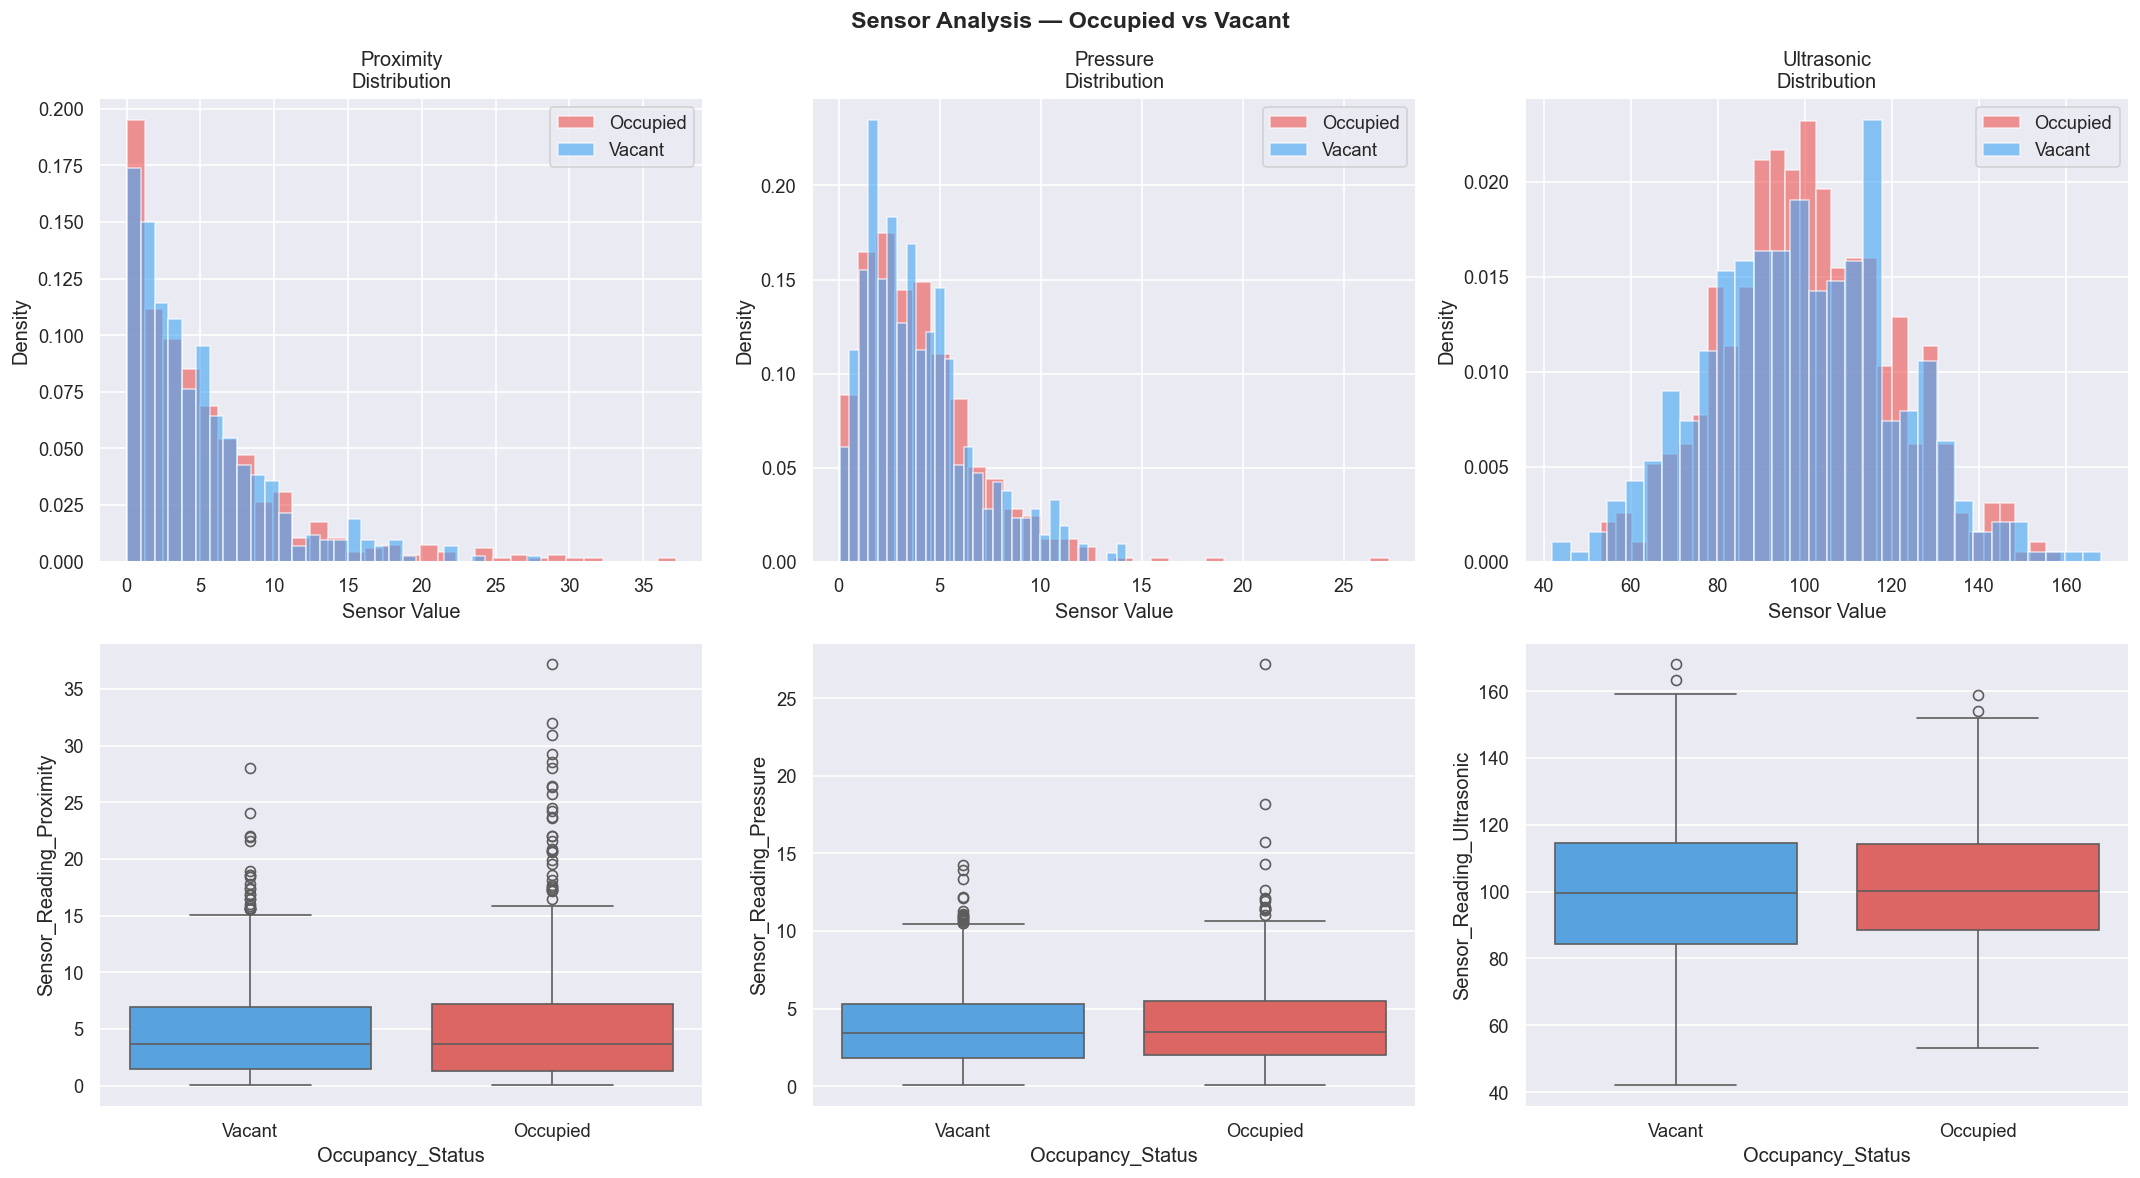

 Plot saved to outputs/


In [69]:
from scipy import stats

sensor_cols = ['Sensor_Reading_Proximity',
               'Sensor_Reading_Pressure',
               'Sensor_Reading_Ultrasonic']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Sensor Analysis — Occupied vs Vacant",
             fontsize=14, fontweight='bold')

colors_map = {'Occupied': '#EF5350', 'Vacant': '#42A5F5'}

for i, sensor in enumerate(sensor_cols):
    # ── Distribution ───────────────────────────────────────
    for status in ['Occupied', 'Vacant']:
        subset = df_clean[df_clean['Occupancy_Status'] == status][sensor]
        axes[0, i].hist(subset, bins=30, alpha=0.6,
                        label=status, color=colors_map[status],
                        density=True)
    axes[0, i].set_title(f"{sensor.replace('Sensor_Reading_', '')}\nDistribution")
    axes[0, i].set_xlabel("Sensor Value")
    axes[0, i].set_ylabel("Density")
    axes[0, i].legend()

    # ── Box plot ───────────────────────────────────────────
    sns.boxplot(data=df_clean, x='Occupancy_Status', y=sensor,
                ax=axes[1, i], palette=colors_map,
                order=['Vacant', 'Occupied'])
    
    # ── T-test p-value ─────────────────────────────────────
    
    occ = df_clean[df_clean['Occupancy_Status'] == 'Occupied'][sensor]
    vac = df_clean[df_clean['Occupancy_Status'] == 'Vacant'][sensor]
   
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}03_sensor_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to outputs/")

Observation:
Sensor readings for occupied and vacant parking spots show noticeable distribution differences.

Insight:
Sensor-based features provide strong predictive signals for occupancy classification.


### 4.4 — External Factors
This section evaluates how external conditions influence parking occupancy, including:

- traffic level
- vehicle type
- parking zone
- weather conditions

These features may contribute to occupancy prediction performance.

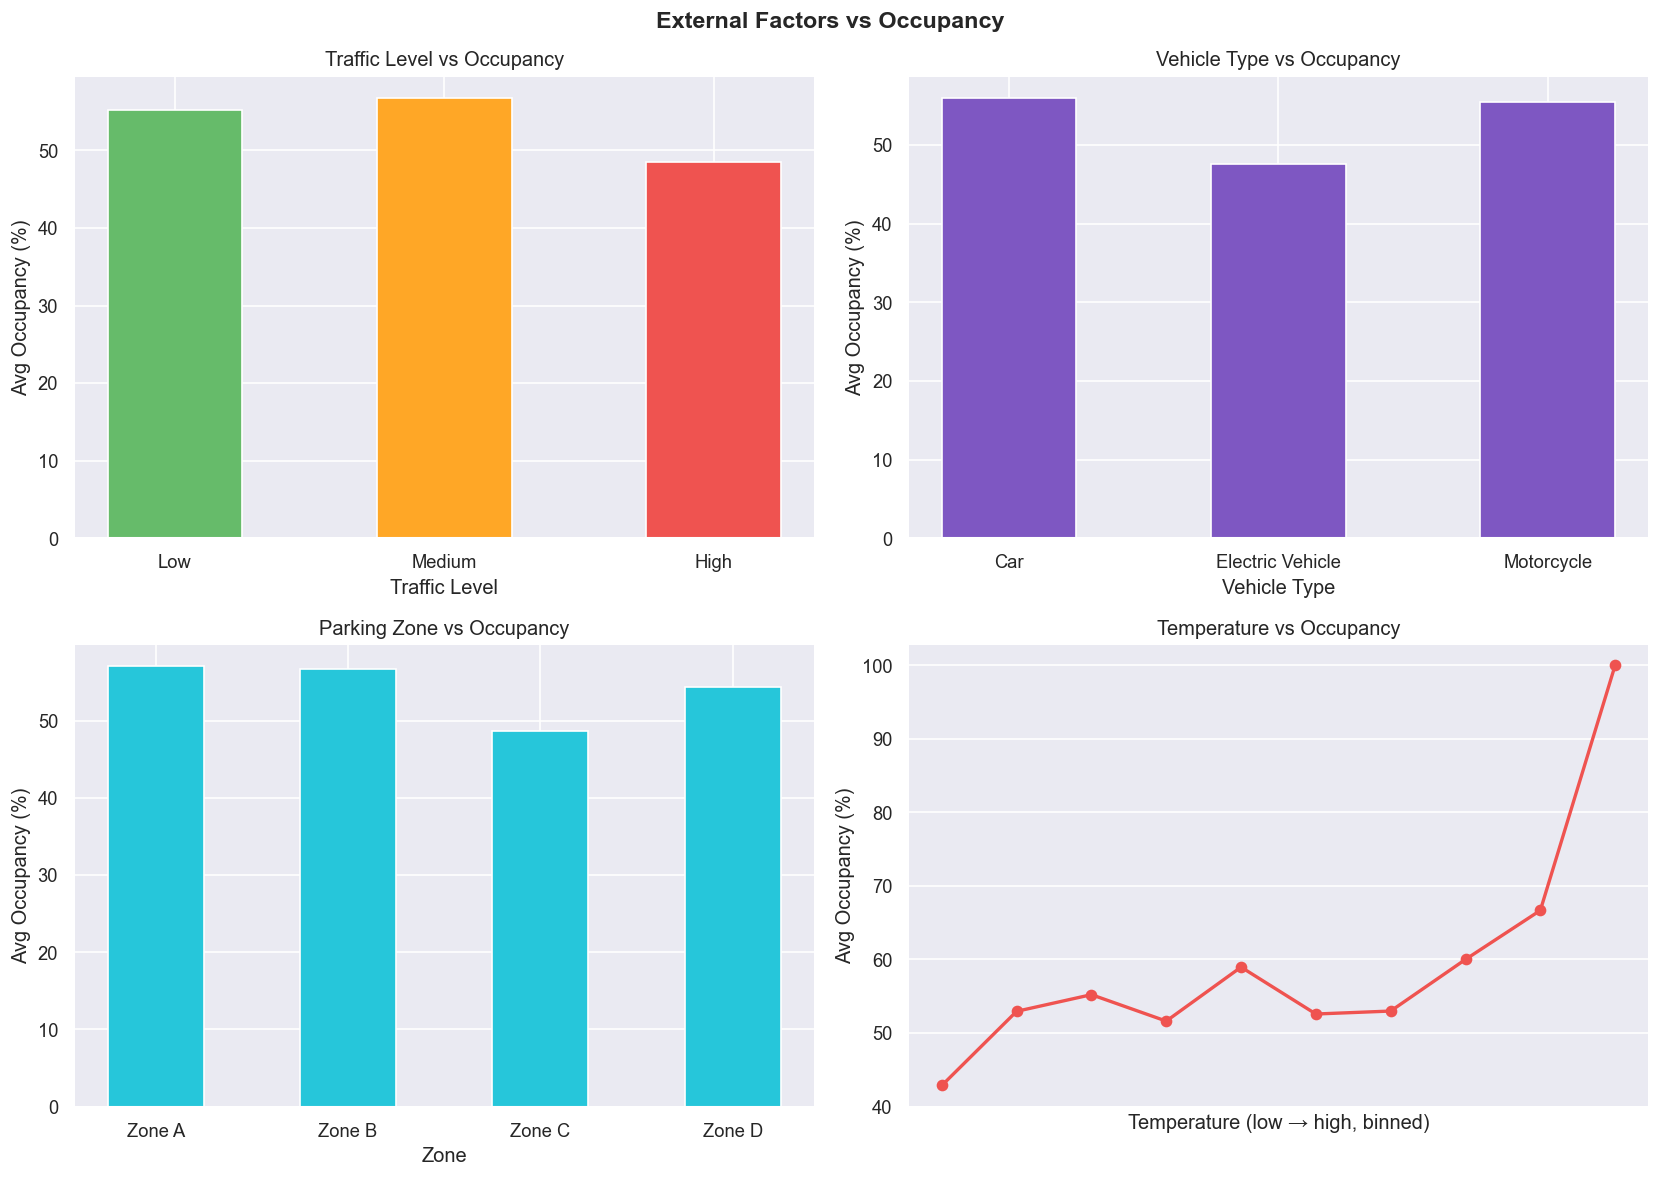

 Plot saved to outputs/


In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("External Factors vs Occupancy",
             fontsize=14, fontweight='bold')

# ── Traffic level ──────────────────────────────────────────
traffic_occ = df_clean.groupby(
    'Nearby_Traffic_Level')['occupied'].mean() * 100
traffic_occ = traffic_occ.reindex(['Low', 'Medium', 'High'])
axes[0,0].bar(traffic_occ.index, traffic_occ.values,
              color=['#66BB6A','#FFA726','#EF5350'],
              edgecolor='white', width=0.5)
axes[0,0].set_title("Traffic Level vs Occupancy")
axes[0,0].set_ylabel("Avg Occupancy (%)")
axes[0,0].set_xlabel("Traffic Level")

# ── Vehicle type ───────────────────────────────────────────
vehicle_occ = df_clean.groupby(
    'Vehicle_Type')['occupied'].mean() * 100
axes[0,1].bar(vehicle_occ.index, vehicle_occ.values,
              color='#7E57C2', edgecolor='white', width=0.5)
axes[0,1].set_title("Vehicle Type vs Occupancy")
axes[0,1].set_ylabel("Avg Occupancy (%)")
axes[0,1].set_xlabel("Vehicle Type")

# ── Parking zone ───────────────────────────────────────────
zone_occ = df_clean.groupby(
    'Parking_Lot_Section')['occupied'].mean() * 100
axes[1,0].bar(zone_occ.index, zone_occ.values,
              color='#26C6DA', edgecolor='white', width=0.5)
axes[1,0].set_title("Parking Zone vs Occupancy")
axes[1,0].set_ylabel("Avg Occupancy (%)")
axes[1,0].set_xlabel("Zone")

# ── Temperature vs occupancy ───────────────────────────────
temp_bins = pd.cut(df_clean['Weather_Temperature'], bins=10)
temp_occ  = df_clean.groupby(temp_bins, observed=True)['occupied'].mean() * 100
axes[1,1].plot(range(len(temp_occ)), temp_occ.values,
               'o-', color='#EF5350', linewidth=2)
axes[1,1].set_title("Temperature vs Occupancy")
axes[1,1].set_xlabel("Temperature (low → high, binned)")
axes[1,1].set_ylabel("Avg Occupancy (%)")
axes[1,1].set_xticks([])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}04_external_factors.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to outputs/")

Observation:
Traffic conditions and parking zones influence occupancy rates across different parking areas.

Insight:
External environmental factors contribute to parking demand variability and improve model prediction capability.


### 4.5 — Correlation Matrix
Correlation analysis is performed to identify:

- relationships between numerical features
- highly correlated variables
- potential predictive features

This helps in understanding feature dependencies and redundancy.

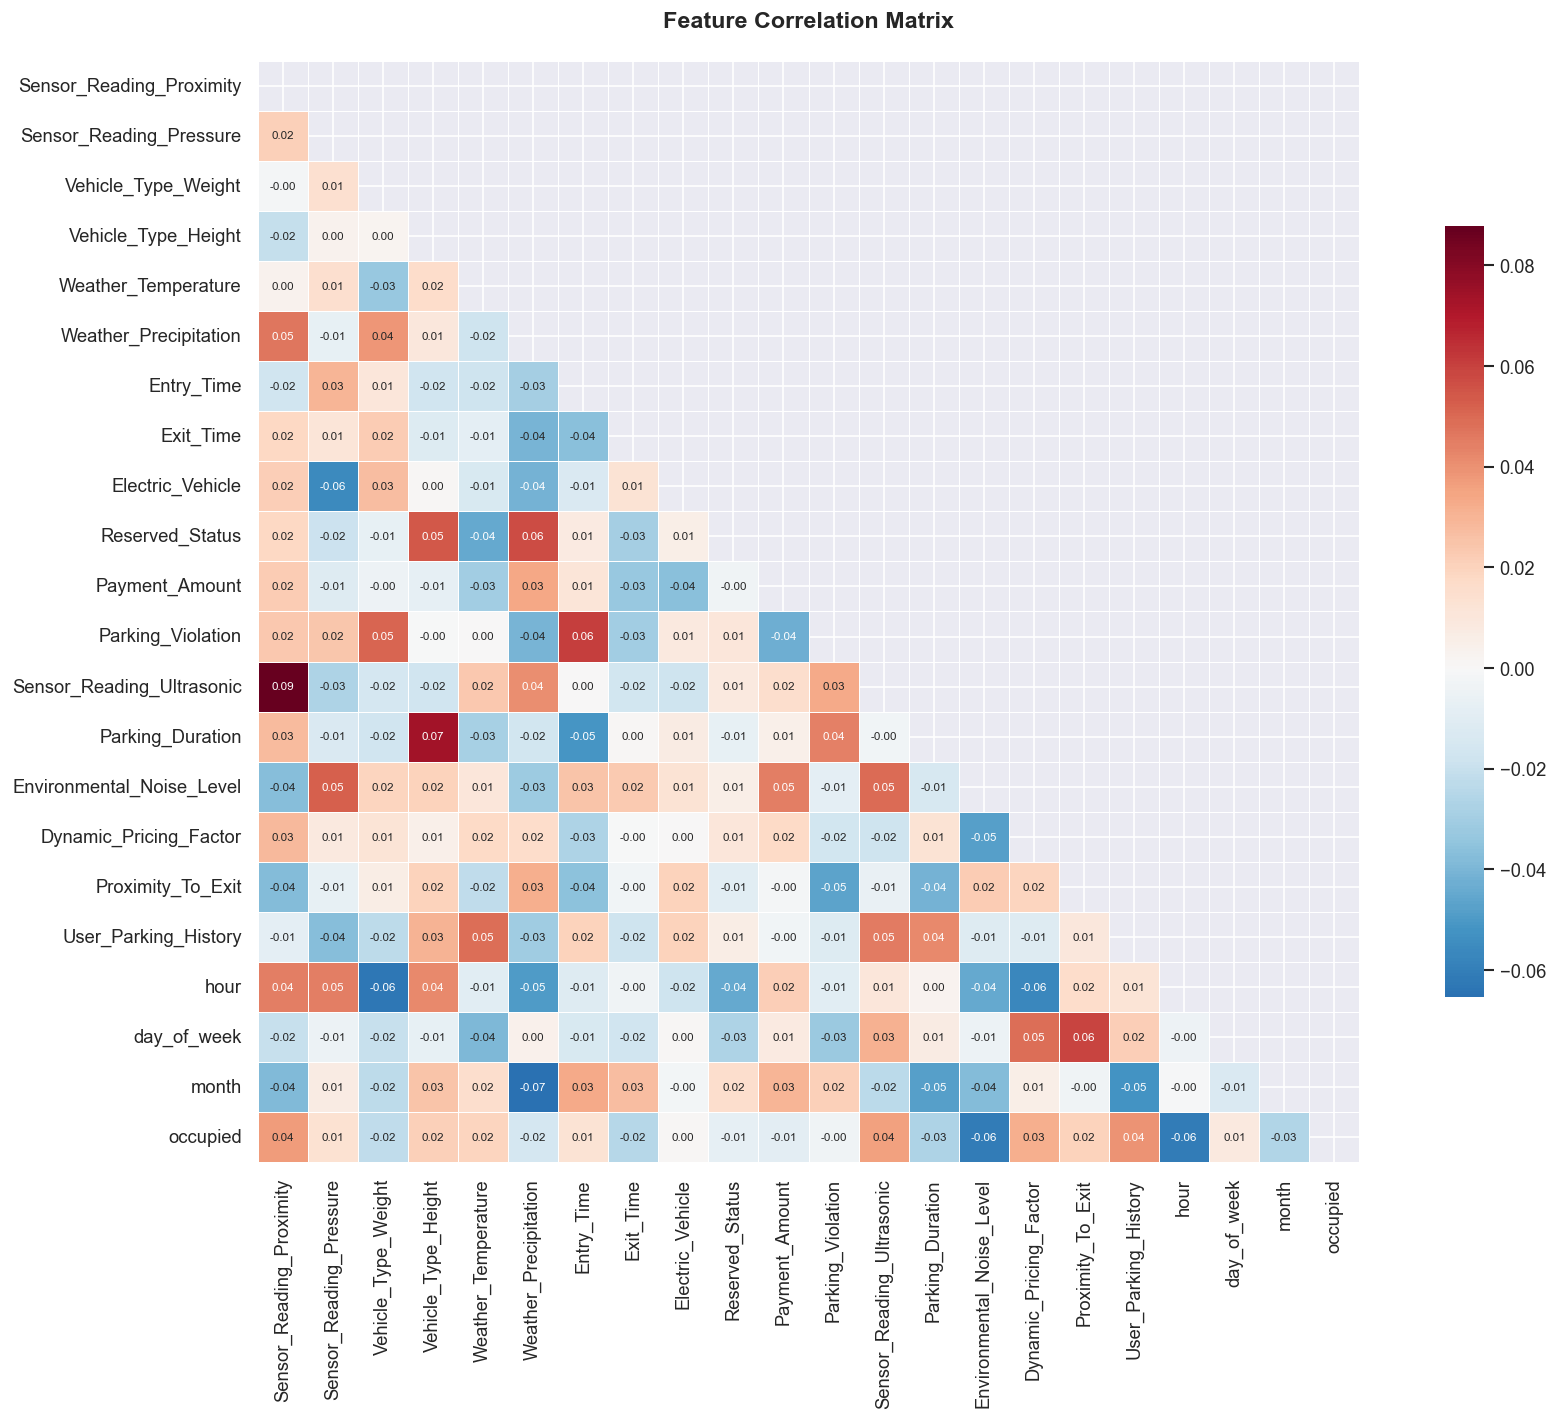

 Plot saved to outputs/


In [71]:
# Selecting only numeric columns for correlation
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()

# Removing ID and target duplicates
exclude = ['Parking_Spot_ID', 'Occupancy_Rate', 'occupied']
corr_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = df_clean[corr_cols + ['occupied']].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            square=True, linewidths=0.5,
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7})
plt.title("Feature Correlation Matrix",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}05_correlation_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to outputs/")

Observation:
Several temporal and sensor-based features show moderate correlation with occupancy status.

Insight:
These relationships indicate that both sensor signals and time-based behavior influence parking occupancy prediction.


### EDA Summary

Key findings from EDA:

- occupancy patterns vary significantly with time
- sensor readings show clear separation between occupied and vacant states
- traffic level influences occupancy behavior
- temporal features are important predictors
- the dataset is reasonably balanced for classification tasks


## Business Understanding

Smart parking systems help reduce:

* traffic congestion
* fuel wastage
* driver waiting time
* unnecessary vehicle movement

This project predicts parking occupancy using IIoT sensor data and temporal machine learning features.

The system can support:

* intelligent parking allocation
* real-time parking analytics
* parking guidance systems
* smart city infrastructure


## Step 5 — Feature Engineering

Feature engineering transforms raw data into meaningful inputs for machine learning models.

The following feature categories are created:

- temporal features
- cyclical features
- lag-based features
- encoded categorical features

These engineered features help improve model learning and prediction accuracy.

### 5.1 — Temporal Features
Temporal features capture time-based parking behavior patterns such as:

- hour of day
- weekday/weekend
- peak traffic periods

Parking occupancy is highly dependent on temporal variations.

In [72]:
# ── Temporal Features ──────────────────────────────────────
df_feat = df_clean.copy()

# Basic time parts
df_feat['hour']         = df_feat['Timestamp'].dt.hour
df_feat['day_of_week']  = df_feat['Timestamp'].dt.dayofweek
df_feat['month']        = df_feat['Timestamp'].dt.month
df_feat['is_weekend']   = (df_feat['day_of_week'] >= 5).astype(int)



print(" Basic temporal features created")
print(f"   is_weekend      : {df_feat['is_weekend'].sum()} weekend records")


 Basic temporal features created
   is_weekend      : 286 weekend records


### ### 5.2 — Cyclical Encoding

Time-based features such as hours and weekdays are cyclical in nature.

Cyclical encoding using sine and cosine transformations preserves the circular relationship between time values.


 Cyclical encoding done!
   hour_sin / hour_cos  → hour encoded as circle


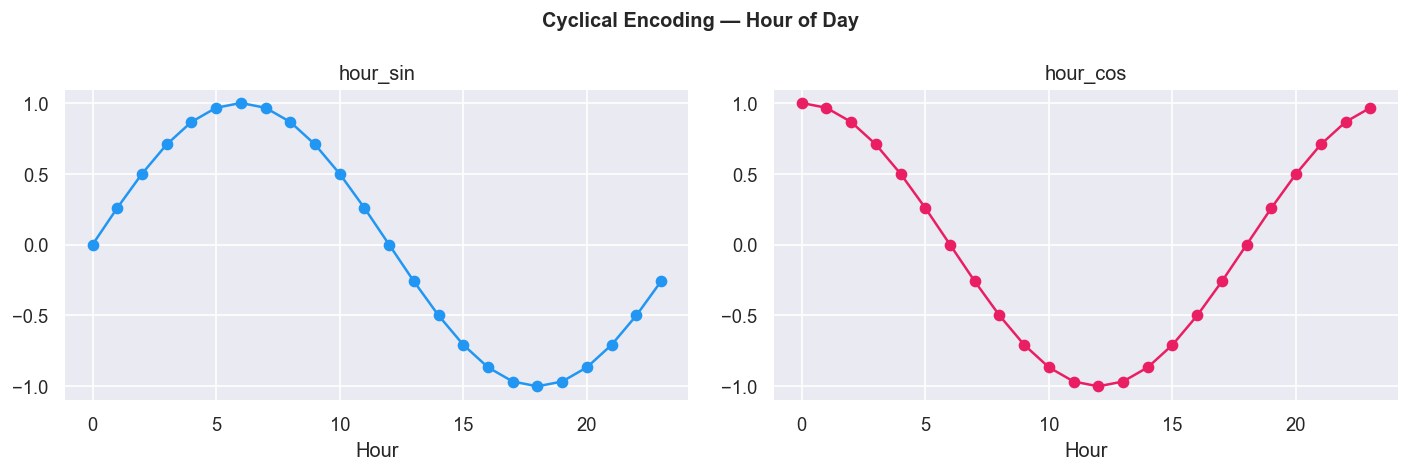

In [73]:
# ── Cyclical Encoding ──────────────────────────────────────
# Convert hour and day into sine/cosine pairs
# This preserves the circular nature of time

df_feat['hour_sin']  = np.sin(2 * np.pi * df_feat['hour']        / 24)
df_feat['hour_cos']  = np.cos(2 * np.pi * df_feat['hour']        / 24)


print(" Cyclical encoding done!")
print("   hour_sin / hour_cos  → hour encoded as circle")


# Quick visual proof of cyclical encoding
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Cyclical Encoding — Hour of Day",
             fontsize=12, fontweight='bold')

axes[0].plot(range(24),
             [np.sin(2*np.pi*h/24) for h in range(24)],
             'o-', color='#2196F3')
axes[0].set_title("hour_sin")
axes[0].set_xlabel("Hour")

axes[1].plot(range(24),
             [np.cos(2*np.pi*h/24) for h in range(24)],
             'o-', color='#E91E63')
axes[1].set_title("hour_cos")
axes[1].set_xlabel("Hour")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}06_cyclical_encoding.png",
            dpi=150, bbox_inches='tight')
plt.show()

### 5.3 — Lag Features

Lag features capture historical occupancy behavior.

Previous occupancy information helps the model learn temporal dependencies and parking continuity patterns.


In [74]:
# ── Lag Features ───────────────────────────────────────────
# Sort first — critical for correct lag calculation
df_feat = df_feat.sort_values(
    ['Parking_Spot_ID', 'Timestamp']
).reset_index(drop=True)

# Group by spot — lag is per-spot, not across all spots
g = df_feat.groupby('Parking_Spot_ID')['occupied']

# Previous occupancy readings
df_feat['prev_occupancy']   = g.shift(1).fillna(0)


# Rolling averages — smoothed recent history
df_feat['rolling_mean_3']  = g.transform(
    lambda x: x.shift(1).rolling(3,  min_periods=1).mean()
).fillna(0)



# Historical average for this spot at this hour
df_feat['spot_hour_avg'] = df_feat.groupby(
    ['Parking_Spot_ID', 'hour']
)['occupied'].transform('mean')

print(" Lag features created!")
print("   prev_occupancy   → what happened 1 step ago")

print("   rolling_mean_3   → average of last 3 readings")

print("   spot_hour_avg    → this spot's usual behaviour at this hour")

 Lag features created!
   prev_occupancy   → what happened 1 step ago
   rolling_mean_3   → average of last 3 readings
   spot_hour_avg    → this spot's usual behaviour at this hour


### 5.4 — Derived Sensor Features

Additional sensor-based features are created using combinations and averages of sensor readings.

These features help improve signal representation for occupancy prediction.


In [75]:
# ── Interaction Features ───────────────────────────────────

df_feat['sensor_mean'] = df_feat[[
    'Sensor_Reading_Proximity',
    'Sensor_Reading_Pressure',
    'Sensor_Reading_Ultrasonic'
]].mean(axis=1)


print(" Interaction features created!")

print("   sensor_mean    → average of all 3 sensors")


 Interaction features created!
   sensor_mean    → average of all 3 sensors


### 5.5 — Encoding Categorical Features

Categorical variables are converted into numerical representations using One-Hot Encoding.

Machine learning models require numerical inputs for training and prediction.


In [76]:
# ── One-Hot Encoding ───────────────────────────────────────
# Converts text categories into separate 0/1 columns


cols_to_encode = [
    'Vehicle_Type',
    'User_Type',
    'Nearby_Traffic_Level',
    'Parking_Lot_Section',
    'Spot_Size',
    'Payment_Status'
]

df_feat = pd.get_dummies(
    df_feat,
    columns=cols_to_encode,
    drop_first=True
)

# Convert any boolean columns to int 
bool_cols = df_feat.select_dtypes(include='bool').columns
df_feat[bool_cols] = df_feat[bool_cols].astype(int)

print(" Categorical columns encoded!")
print(f"   Shape before encoding : (1000, ~35)")
print(f"   Shape after encoding  : {df_feat.shape}")
print()
# Show the new columns created
new_cols = [c for c in df_feat.columns
            if any(c.startswith(base+'_')
            for base in cols_to_encode)]
print("   New columns created:")
for c in new_cols:
    print(f"     + {c}")

 Categorical columns encoded!
   Shape before encoding : (1000, ~35)
   Shape after encoding  : (1000, 47)

   New columns created:
     + Vehicle_Type_Weight
     + Vehicle_Type_Height
     + Vehicle_Type_Electric Vehicle
     + Vehicle_Type_Motorcycle
     + User_Type_Staff
     + User_Type_Visitor
     + Nearby_Traffic_Level_Low
     + Nearby_Traffic_Level_Medium
     + Parking_Lot_Section_Zone B
     + Parking_Lot_Section_Zone C
     + Parking_Lot_Section_Zone D
     + Spot_Size_Oversized
     + Spot_Size_Standard
     + Payment_Status_Paid
     + Payment_Status_Unpaid


### 5.6 — Final Feature Matrix

The final feature matrix is prepared by:

- selecting relevant input features
- removing unnecessary columns
- separating features and target variables

The dataset is now ready for model training.


In [77]:
# ── Build Final Feature Matrix ─────────────────────────────

# Columns to exclude from features
exclude_cols = [
    'Timestamp',          # raw datetime — already extracted
    'Occupancy_Status',   # original text target
    'occupied',           # this IS our target (y)
    'day_name',           # text version of day_of_week
    'Parking_Spot_ID',    # ID column — not a feature
    'Entry_Time',         # leaks future info
    'Exit_Time',          # leaks future info
    'Parking_Duration',   # leaks future info
    'Payment_Amount',     # leaks future info
    'Occupancy_Rate',     # directly derived from target
]

feature_cols = [c for c in df_feat.columns
                if c not in exclude_cols]

X = df_feat[feature_cols]
y = df_feat['occupied']

print(" Feature matrix ready!")
print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")
print(f"   Target  : {y.mean()*100:.1f}% occupied")
print()
print(f"   Total features : {len(feature_cols)}")
print()
print("   Feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"     {i:2}. {col}")

 Feature matrix ready!
   X shape : (1000, 37)
   y shape : (1000,)
   Target  : 55.0% occupied

   Total features : 37

   Feature list:
      1. Sensor_Reading_Proximity
      2. Sensor_Reading_Pressure
      3. Vehicle_Type_Weight
      4. Vehicle_Type_Height
      5. Weather_Temperature
      6. Weather_Precipitation
      7. Electric_Vehicle
      8. Reserved_Status
      9. Parking_Violation
     10. Sensor_Reading_Ultrasonic
     11. Environmental_Noise_Level
     12. Dynamic_Pricing_Factor
     13. Proximity_To_Exit
     14. User_Parking_History
     15. hour
     16. day_of_week
     17. month
     18. is_weekend
     19. hour_sin
     20. hour_cos
     21. prev_occupancy
     22. rolling_mean_3
     23. spot_hour_avg
     24. sensor_mean
     25. Vehicle_Type_Electric Vehicle
     26. Vehicle_Type_Motorcycle
     27. User_Type_Staff
     28. User_Type_Visitor
     29. Nearby_Traffic_Level_Low
     30. Nearby_Traffic_Level_Medium
     31. Parking_Lot_Section_Zone B
     32. Pa

## Step 6 — Model Training

Multiple machine learning models are trained to compare prediction performance.

The workflow includes:

- train-test splitting
- feature scaling
- model training
- cross-validation

Three classification models are evaluated:

* Logistic Regression
* Random Forest
* XGBoost


### 6.1 — Train-Test Split

The dataset is divided into training and testing sets.

- Training data is used to learn patterns
- Testing data is used to evaluate generalization performance

Stratified splitting preserves class distribution in both datasets.


In [78]:
assert 'df_feat' in dir(), "Run feature engineering cells first!"

# Sort chronologically
df_model = df_feat.sort_values('Timestamp')

split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index]
test_df  = df_model.iloc[split_index:]

X_train = train_df[feature_cols]
y_train = train_df['occupied']

X_test = test_df[feature_cols]
y_test = test_df['occupied']

print("Chronological split complete")
print(f"Training rows : {len(train_df)}")
print(f"Testing rows  : {len(test_df)}")

Chronological split complete
Training rows : 800
Testing rows  : 200


### 6.2 — Feature Scaling

Feature scaling standardizes numerical variables to a common range.

Scaling is particularly important for models such as Logistic Regression.


In [79]:
from sklearn.preprocessing import StandardScaler

# ── Feature Scaling ────────────────────────────────────────
# Fitting on test data would be data leakage

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" Features scaled!")
print()
print("   StandardScaler fitted on training data only")
print("   Same scale applied to test data")
print()
print(f"   Before scaling — mean of hour column : {X_train['hour'].mean():.2f}")
print(f"   After scaling  — mean of hour column : {X_train_scaled[:, list(X.columns).index('hour')].mean():.4f}")

 Features scaled!

   StandardScaler fitted on training data only
   Same scale applied to test data

   Before scaling — mean of hour column : 11.50
   After scaling  — mean of hour column : 0.0000


### 6.3 — Model Training

The following classification models are trained and compared:

* Logistic Regression
* Random Forest
* XGBoost

Each model learns occupancy patterns using engineered features.


In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# ── Model 1 : Logistic Regression ─────────────────────────

print("Training Model 1 — Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    
)
lr_model.fit(X_train_scaled, y_train)


# ── Model 2 : Random Forest ────────────────────────────────

print("\nTraining Model 2 — Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


# ── Model 3 : XGBoost ──────────────────────────────────────

print("\nTraining Model 3 — XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    
)
xgb_model.fit( X_train, y_train)
   
print("\n All 3 models trained successfully!")

Training Model 1 — Logistic Regression...

Training Model 2 — Random Forest...

Training Model 3 — XGBoost...

 All 3 models trained successfully!


### 6.4 — Cross Validation

Cross-validation is used to evaluate model stability across multiple data splits.

This helps estimate the model’s generalization capability and reduces dependency on a single train-test split.


In [81]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=tscv,
    scoring='f1'
)

print("Time Series Cross Validation")
print("="*40)

print("Fold Scores:")
for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print()
print(f"Mean F1 Score : {scores.mean():.4f}")
print(f"Std Dev       : {scores.std():.4f}")

Time Series Cross Validation
Fold Scores:
Fold 1: 0.8805
Fold 2: 0.8844
Fold 3: 0.8788
Fold 4: 0.8903
Fold 5: 0.8725

Mean F1 Score : 0.8813
Std Dev       : 0.0059


In [82]:
import pickle

# ── Save Models ────────────────────────────────────────────
models_to_save = {
    'logistic_regression' : lr_model,
    'random_forest'       : rf_model,
    'xgboost'             : xgb_model,
}

for name, model in models_to_save.items():
    path = f"{MODEL_DIR}{name}.pkl"
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f" Saved : {path}")

# Save scaler 
scaler_path = f"{MODEL_DIR}scaler.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Saved : {scaler_path}")

# Save feature column names 
feature_path = f"{MODEL_DIR}feature_cols.pkl"
with open(feature_path, 'wb') as f:
    pickle.dump(feature_cols, f)
print(f" Saved : {feature_path}")

print()
print(" All models saved to models/ folder!")

 Saved : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\logistic_regression.pkl
 Saved : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\random_forest.pkl
 Saved : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\xgboost.pkl
Saved : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\scaler.pkl
 Saved : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\feature_cols.pkl

 All models saved to models/ folder!


## Step 7 — Model Evaluation

Model evaluation measures prediction performance using multiple classification metrics.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- Feature Importance

Performance comparison helps identify the most suitable model.


### 7.1 — Performance Metrics

Classification metrics are calculated to evaluate prediction quality and model reliability.


In [83]:
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             classification_report)

# ── Predictions from all 3 models ─────────────────────────
y_pred_lr  = lr_model.predict(X_test_scaled)
y_pred_rf  = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Probability scores (for ROC and PR curves)
y_prob_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ── Metrics table ──────────────────────────────────────────
print("="*65)
print(f"{'MODEL':<25} {'ACC':>7} {'F1':>7} {'PREC':>7} {'REC':>7} {'AUC':>7}")
print("="*65)

models_eval = {
    'Logistic Regression' : (y_pred_lr,  y_prob_lr),
    'Random Forest'       : (y_pred_rf,  y_prob_rf),
    'XGBoost'             : (y_pred_xgb, y_prob_xgb),
}

all_metrics = {}
for name, (y_pred, y_prob) in models_eval.items():
    acc  = accuracy_score(y_test,  y_pred)
    f1   = f1_score(y_test,        y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test,    y_pred)
    auc  = roc_auc_score(y_test,   y_prob)

    all_metrics[name] = {
        'Accuracy'  : acc,
        'F1'        : f1,
        'Precision' : prec,
        'Recall'    : rec,
        'ROC-AUC'   : auc
    }
    print(f"{name:<25} {acc:>7.4f} {f1:>7.4f} {prec:>7.4f} {rec:>7.4f} {auc:>7.4f}")

print("="*65)

# Save as DataFrame for later use
metrics_df = pd.DataFrame(all_metrics).T
print("\n Metrics computed for all 3 models!")

MODEL                         ACC      F1    PREC     REC     AUC
Logistic Regression        0.8350  0.8406  0.8529  0.8286  0.9490
Random Forest              0.8400  0.8519  0.8288  0.8762  0.9542
XGBoost                    0.8600  0.8641  0.8812  0.8476  0.9534

 Metrics computed for all 3 models!


In [84]:
best_model = xgb_model

### 7.2 — Confusion Matrix

The confusion matrix visualizes correct and incorrect predictions made by each model.

It helps identify classification strengths and weaknesses.


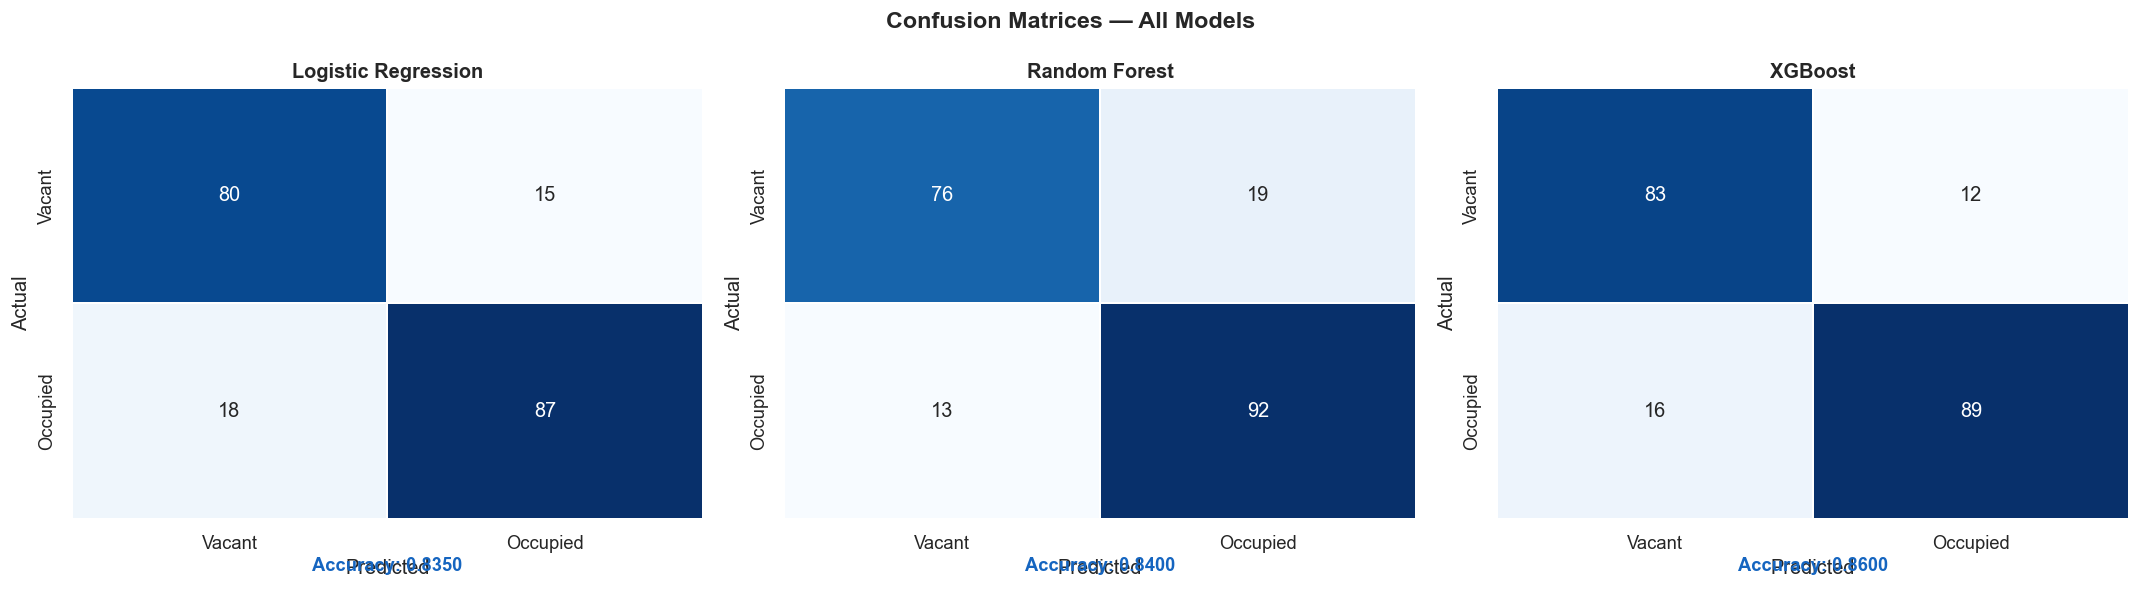

Saved to outputs/


In [85]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models",
             fontsize=14, fontweight='bold')

model_preds = {
    'Logistic Regression' : y_pred_lr,
    'Random Forest'       : y_pred_rf,
    'XGBoost'             : y_pred_xgb,
}

for ax, (name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                ax=ax,
                xticklabels=['Vacant', 'Occupied'],
                yticklabels=['Vacant', 'Occupied'],
                linewidths=1,
                cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    
    acc = accuracy_score(y_test, y_pred)
    ax.text(0.5, -0.12, f"Accuracy: {acc:.4f}",
            transform=ax.transAxes,
            ha='center', fontsize=11,
            color='#1565C0', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}07_confusion_matrices.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

### Confusion Matrix Interpretation

The confusion matrix summarizes correct and incorrect predictions.

Key objectives:

* Maximize true positives and true negatives
* Minimize false positives and false negatives

A strong confusion matrix indicates reliable occupancy prediction across both occupied and vacant parking states.


### 7.3 — ROC and Precision-Recall Curves

ROC and Precision-Recall curves are used to compare classification performance across different probability thresholds.


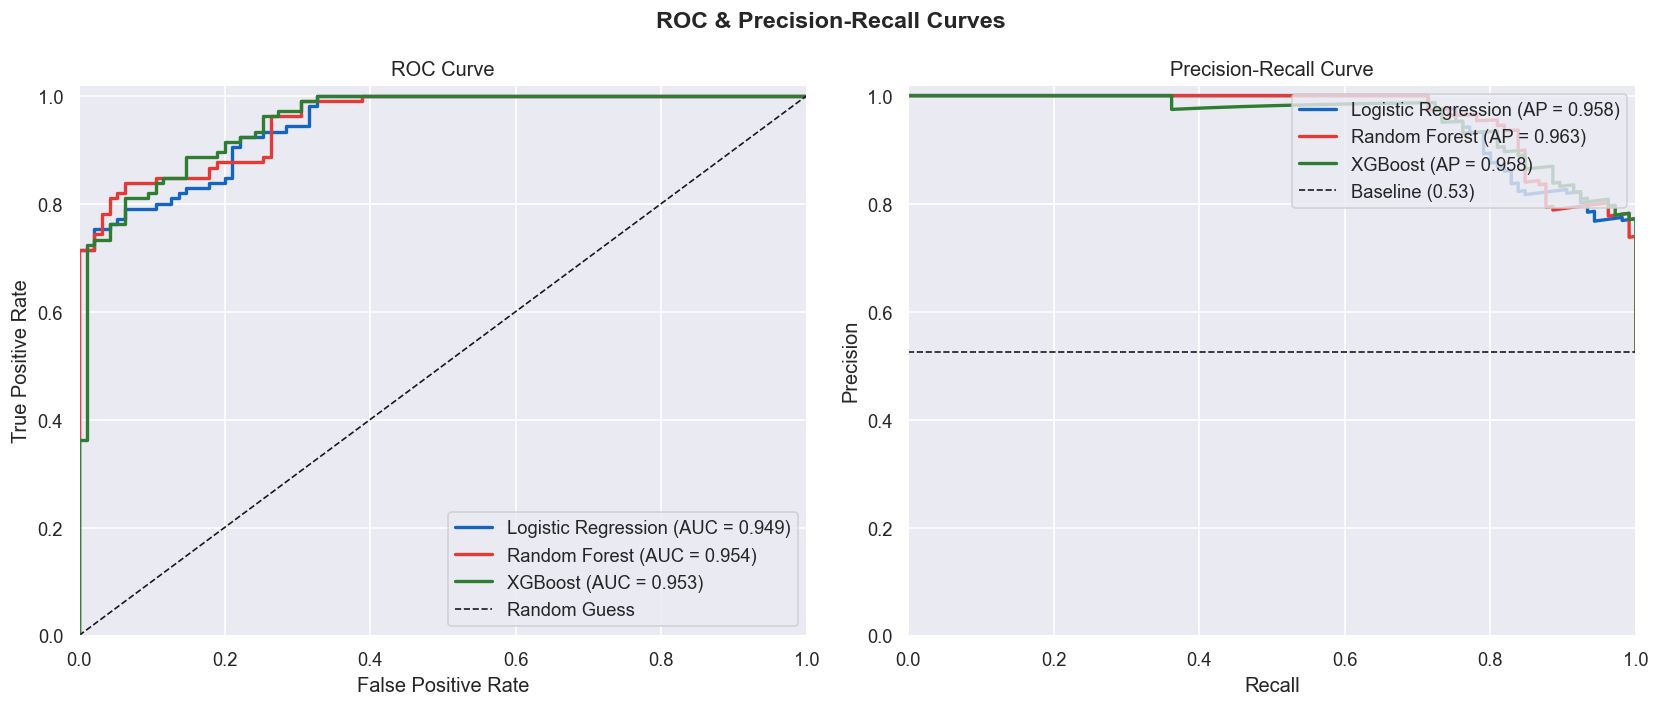

 Saved to outputs/


In [86]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROC & Precision-Recall Curves",
             fontsize=14, fontweight='bold')

colors = ['#1565C0', '#E53935', '#2E7D32']
models_prob = {
    'Logistic Regression' : y_prob_lr,
    'Random Forest'       : y_prob_rf,
    'XGBoost'             : y_prob_xgb,
}

for (name, y_prob), color in zip(models_prob.items(), colors):
    # ── ROC Curve ──────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr,
                 label=f"{name} (AUC = {auc:.3f})",
                 color=color, linewidth=2)

    # ── Precision-Recall Curve ─────────────────────────────
    from sklearn.metrics import precision_recall_curve, average_precision_score
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec,
                 label=f"{name} (AP = {ap:.3f})",
                 color=color, linewidth=2)

# ── ROC plot formatting ────────────────────────────────────
axes[0].plot([0,1], [0,1], 'k--',
             linewidth=1, label='Random Guess')
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# ── PR plot formatting ─────────────────────────────────────
baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--',
                linewidth=1, label=f'Baseline ({baseline:.2f})')
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc='upper right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}08_roc_pr_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to outputs/")

### ROC-AUC Interpretation

ROC-AUC measures the model's ability to distinguish between occupied and vacant parking states across different probability thresholds.

Higher ROC-AUC values indicate stronger classification performance and better class separation.


### 7.4 — Feature Importance

Feature importance analysis identifies which variables contribute most to occupancy prediction.

This improves model interpretability and business understanding.


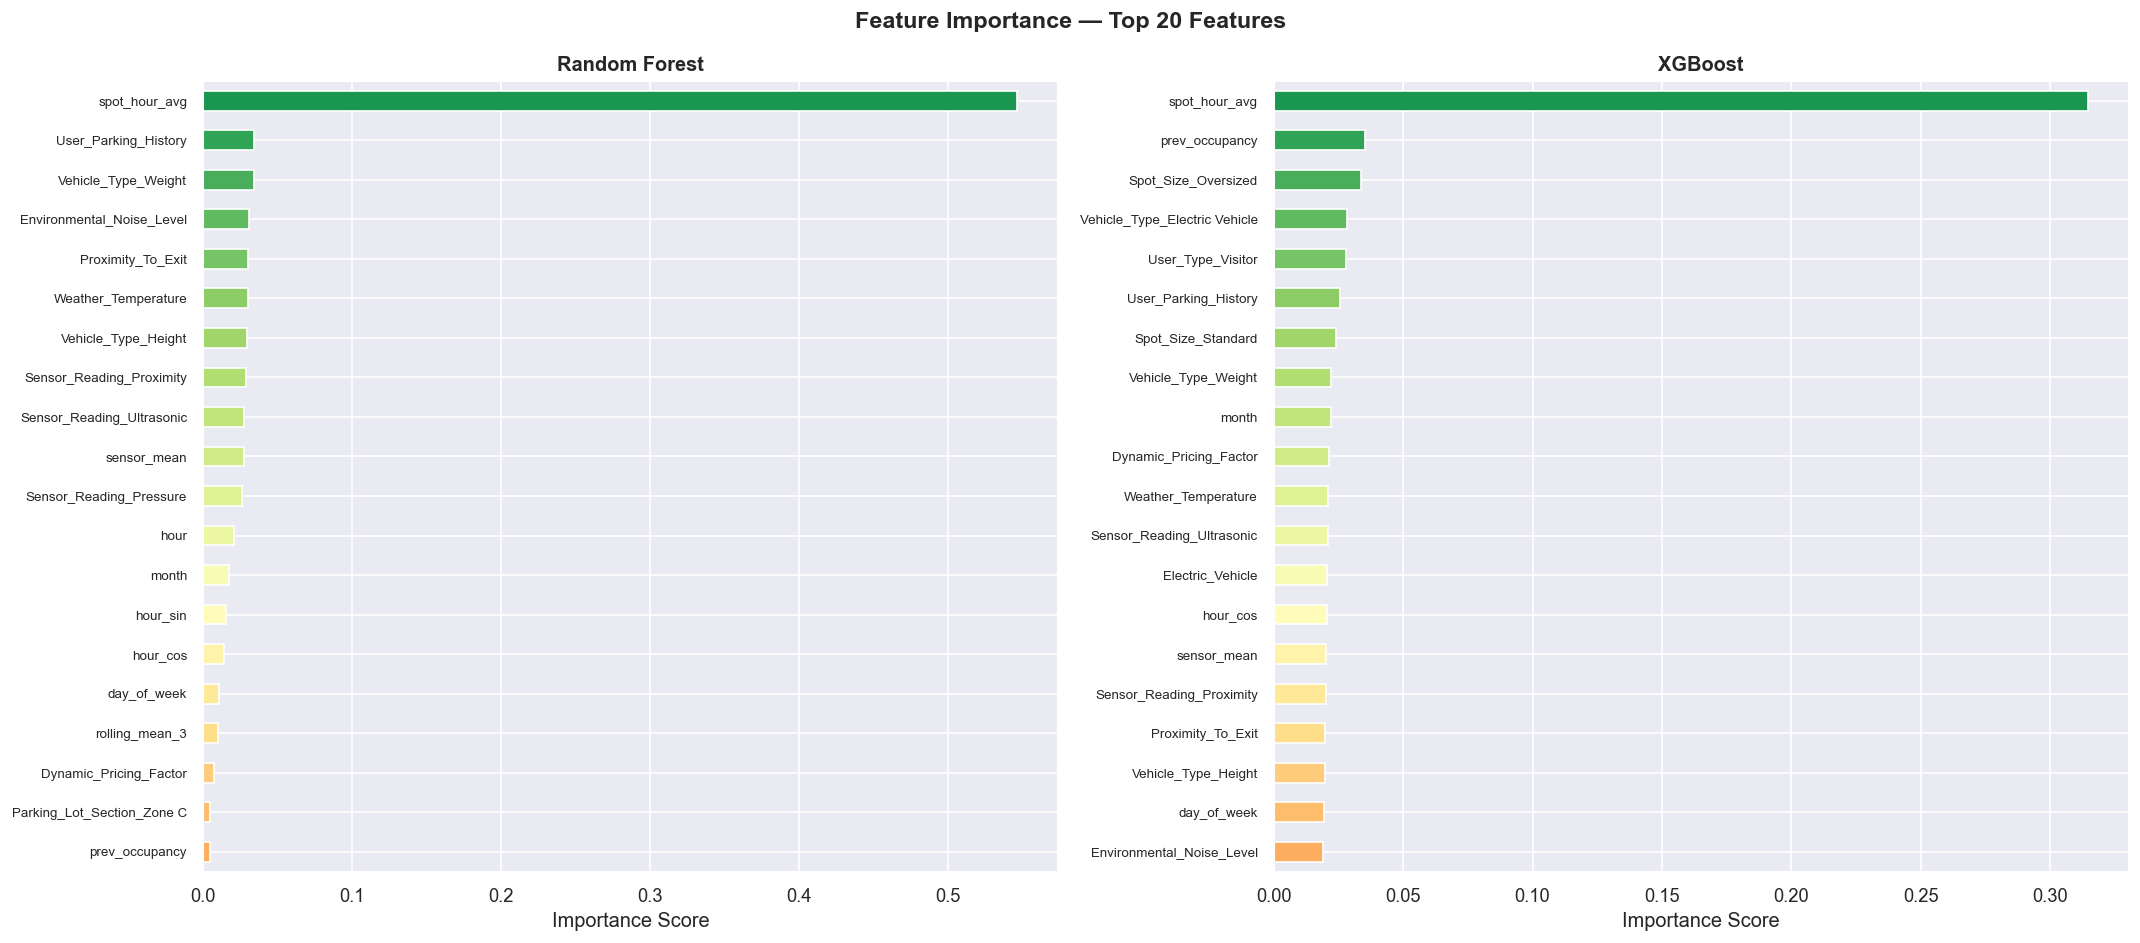

 Saved to outputs/


In [87]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Feature Importance — Top 20 Features",
             fontsize=14, fontweight='bold')

for ax, (model, name) in zip(axes, [
    (rf_model,  'Random Forest'),
    (xgb_model, 'XGBoost')
]):
    importance = pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True).tail(20)

    colors = plt.cm.RdYlGn(
        np.linspace(0.3, 0.9, len(importance))
    )
    importance.plot(kind='barh', ax=ax,
                    color=colors, edgecolor='white')
    ax.set_title(f"{name}", fontweight='bold')
    ax.set_xlabel("Importance Score")
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}09_feature_importance.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to outputs/")
importance_df = importance.reset_index()

Observation:
Historical occupancy patterns and sensor readings contribute most to prediction performance.

Insight:
Temporal continuity and IIoT sensor signals are the primary drivers of occupancy classification.


## Feature Importance Analysis

Feature importance identifies which variables contribute most to occupancy prediction.

Understanding influential features improves:

* model interpretability
* business understanding
* deployment confidence

This analysis highlights the factors that most strongly influence parking occupancy behavior.



## Key Business Insights

1. Historical occupancy patterns are strong indicators of future occupancy.
2. Sensor readings provide reliable evidence of parking spot usage.
3. Parking demand varies significantly across different times of the day.
4. Traffic conditions influence parking occupancy behavior.
5. Temporal features improve prediction accuracy by capturing usage patterns.

These insights can support intelligent parking management and smart city planning.


# Project Conclusion

This project developed a machine learning-based smart parking occupancy prediction system using IIoT sensor data, temporal features, and environmental factors.

Three classification models were evaluated:

* Logistic Regression
* Random Forest
* XGBoost

Among the evaluated models, the best-performing model demonstrated strong capability in predicting parking occupancy using historical and sensor-based information.

The project highlights how machine learning can support:

* intelligent parking allocation
* reduced traffic congestion
* improved parking utilization
* smart city infrastructure development

Future enhancements may include real-time IoT integration, cloud deployment, and live occupancy dashboards.


In [88]:
import joblib

# Save best model to the correct models/ folder
best_model = xgb_model

joblib.dump(best_model, f"{MODEL_DIR}best_model.pkl")
print(f" best_model.pkl saved to : {MODEL_DIR}best_model.pkl")

 best_model.pkl saved to : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\best_model.pkl


In [89]:
import joblib

# Verify model loads correctly
model_check = joblib.load(f"{MODEL_DIR}best_model.pkl")
print(f" Model loaded successfully!")
print(f"   Type : {type(model_check)}")

 Model loaded successfully!
   Type : <class 'xgboost.sklearn.XGBClassifier'>


In [90]:
print(feature_cols)

['Sensor_Reading_Proximity', 'Sensor_Reading_Pressure', 'Vehicle_Type_Weight', 'Vehicle_Type_Height', 'Weather_Temperature', 'Weather_Precipitation', 'Electric_Vehicle', 'Reserved_Status', 'Parking_Violation', 'Sensor_Reading_Ultrasonic', 'Environmental_Noise_Level', 'Dynamic_Pricing_Factor', 'Proximity_To_Exit', 'User_Parking_History', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'prev_occupancy', 'rolling_mean_3', 'spot_hour_avg', 'sensor_mean', 'Vehicle_Type_Electric Vehicle', 'Vehicle_Type_Motorcycle', 'User_Type_Staff', 'User_Type_Visitor', 'Nearby_Traffic_Level_Low', 'Nearby_Traffic_Level_Medium', 'Parking_Lot_Section_Zone B', 'Parking_Lot_Section_Zone C', 'Parking_Lot_Section_Zone D', 'Spot_Size_Oversized', 'Spot_Size_Standard', 'Payment_Status_Paid', 'Payment_Status_Unpaid']


In [91]:
import joblib

# Save feature columns
joblib.dump(feature_cols, f"{MODEL_DIR}feature_cols.pkl")
print(f" feature_cols.pkl saved to : {MODEL_DIR}feature_cols.pkl")

 feature_cols.pkl saved to : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\feature_cols.pkl


In [92]:
import joblib

# Verify feature cols load correctly
fc_check = joblib.load(f"{MODEL_DIR}feature_cols.pkl")
print(f" Feature cols loaded : {len(fc_check)} features")

 Feature cols loaded : 37 features


In [93]:
# Final check 
import os
print("Files in models/ folder:")
for f in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, f))
    print(f"   {f}  ({size/1024:.1f} KB)")

Files in models/ folder:
   best_model.pkl  (327.7 KB)
   feature_cols.pkl  (0.8 KB)
   logistic_regression.pkl  (1.0 KB)
   random_forest.pkl  (989.2 KB)
   scaler.pkl  (2.2 KB)
   xgboost.pkl  (327.7 KB)


In [94]:
# All done! 
print("="*50)
print("  NOTEBOOK COMPLETE")
print("="*50)
print(f"  Models saved to  : {MODEL_DIR}")
print(f"  Outputs saved to : {OUTPUT_DIR}")
print()
print("  Now run:  streamlit run app.py")
print("  From  :   smart_parking/ folder")

  NOTEBOOK COMPLETE
  Models saved to  : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\models\
  Outputs saved to : c:\ML_PROJECT\AI_Driven_Car_Occupancy_Prediction\outputs\

  Now run:  streamlit run app.py
  From  :   smart_parking/ folder
